# Wine Cultivar Recognition
End-to-end ML classification on the sklearn `load_wine` dataset (178 samples, 13 features, 3 classes).
Run the cells top to bottom — each step builds on variables from the ones above.

## Imports

In [67]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

## 1. Load & explore

In [68]:
data = load_wine()

In [69]:
X, y = data.data, data.target

In [70]:
feature_names, target_names = list(data.feature_names), list(data.target_names)

In [71]:
print(feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [72]:
print(f"Classes          : {target_names}")

Classes          : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [73]:
counts = np.bincount(y)

In [74]:
print(f"Samples          : {X.shape[0]}")

Samples          : 178


In [75]:
print(f"Features         : {X.shape[1]}")

Features         : 13


In [76]:
print("Class counts     :", dict(zip(target_names, counts)))

Class counts     : {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}


In [77]:
print(f"Balanced?        : {'roughly yes' if counts.max() / counts.min() < 1.5 else 'no'}")

Balanced?        : roughly yes


In [78]:
print(f"Any missing?     : {np.isnan(X).any()}")

Any missing?     : False


## 2. Explore visually (EDA)
Build intuition for the data *before* modeling — this is what explains the near-perfect scores later.

### 2a. Feature correlation heatmap — which features move together

In [79]:
corr = np.corrcoef(X.T)

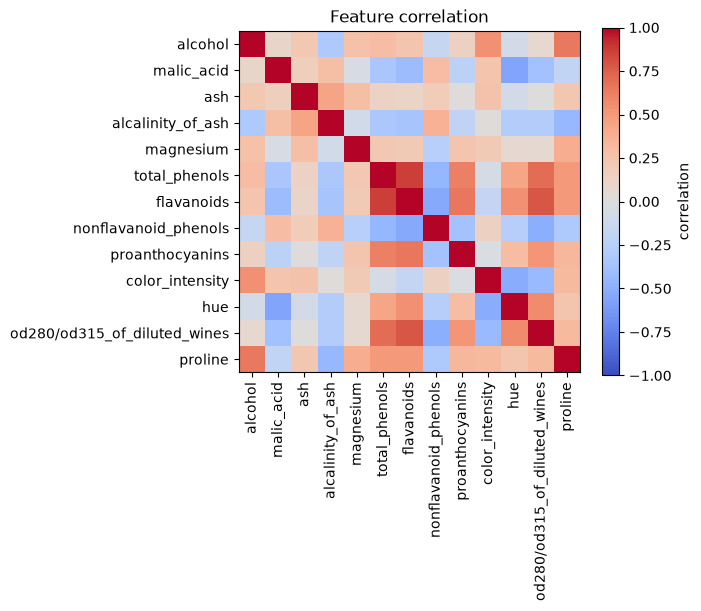

In [80]:
plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="correlation")
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature correlation")
plt.tight_layout()
plt.show()

### 2b. PCA scatter — are the 3 classes actually separable in 2D?

In [81]:
X_std = StandardScaler().fit_transform(X)

In [82]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

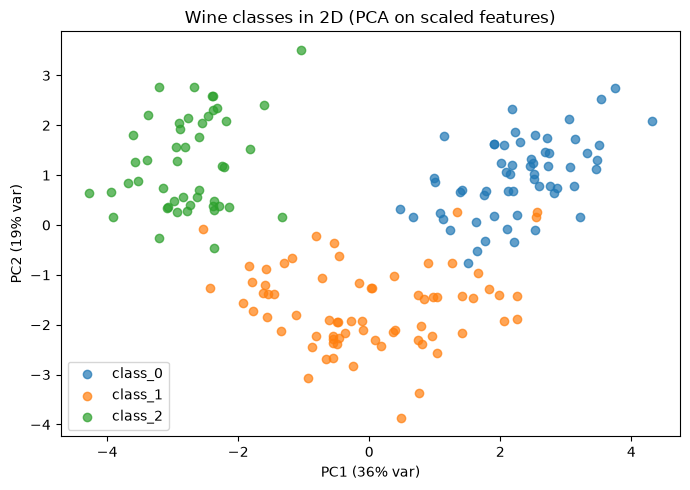

In [83]:
plt.figure(figsize=(7, 5))
for cls in np.unique(y):
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=target_names[cls], alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
plt.title("Wine classes in 2D (PCA on scaled features)")
plt.legend()
plt.tight_layout()
plt.show()

### 2c. Distribution of one feature by class

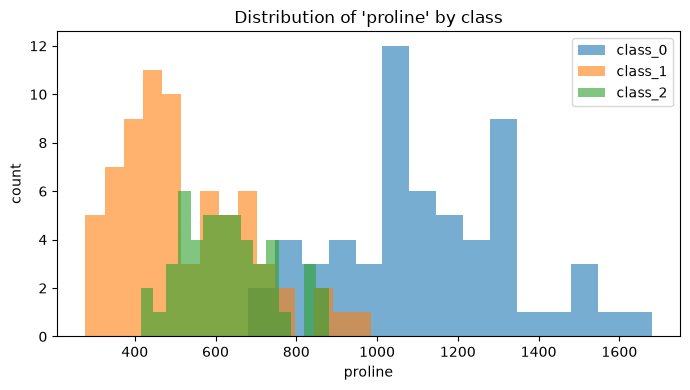

In [84]:
feat = "proline"
j = feature_names.index(feat)
plt.figure(figsize=(7, 4))
for cls in np.unique(y):
    plt.hist(X[y == cls, j], bins=15, alpha=0.6, label=target_names[cls])
plt.xlabel(feat)
plt.ylabel("count")
plt.title(f"Distribution of '{feat}' by class")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Train / test split

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

In [86]:
print(f"Train / test    : {X_train.shape[0]} / {X_test.shape[0]} samples")

Train / test    : 133 / 45 samples


## 4. Compare models (5-fold CV, scoring = f1_macro)

In [87]:
candidates = {
    "LogReg":       Pipeline([("scaler", StandardScaler()),
                              ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "SVM (RBF)":    Pipeline([("scaler", StandardScaler()),
                              ("clf", SVC(kernel="rbf", random_state=42))]),
    "RandomForest": Pipeline([("scaler", StandardScaler()),
                              ("clf", RandomForestClassifier(n_estimators=200, random_state=42))]),
}

In [88]:
cv_results = {}
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1_macro")
    cv_results[name] = scores
    print(f"{name:14s}: {scores.mean():.4f} +- {scores.std():.4f}")

LogReg        : 0.9854 +- 0.0180
SVM (RBF)     : 0.9924 +- 0.0152
RandomForest  : 0.9706 +- 0.0147


In [89]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())

In [90]:
print(f"\nBest baseline    : {best_name}")


Best baseline    : SVM (RBF)


## 5. Why scaling matters
The pipelines above scale features first. Here's the same SVM *with* vs *without* scaling — proof it isn't decorative.

In [91]:
svm_scaled = Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", random_state=42))])
svm_raw = SVC(kernel="rbf", random_state=42)

In [92]:
s_scaled = cross_val_score(svm_scaled, X_train, y_train, cv=5, scoring="f1_macro").mean()
s_raw = cross_val_score(svm_raw, X_train, y_train, cv=5, scoring="f1_macro").mean()

In [93]:
print(f"SVM with scaling   : {s_scaled:.4f}")
print(f"SVM without scaling: {s_raw:.4f}")
print(f"Scaling gained     : {s_scaled - s_raw:+.4f} f1_macro")

SVM with scaling   : 0.9924
SVM without scaling: 0.5225
Scaling gained     : +0.4699 f1_macro


## 6. Hyperparameter tuning (GridSearchCV on RandomForest)

In [94]:
pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", RandomForestClassifier(random_state=42))])

In [95]:
param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 5, 10],
    "clf__min_samples_leaf": [1, 2],
}

In [96]:
grid = GridSearchCV(pipe, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)

In [97]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__max_depth': [None, 5, ...], 'clf__min_samples_leaf': [1, 2], 'clf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: i

In [98]:
best_model = grid.best_estimator_

In [99]:
print(f"Best params      : {grid.best_params_}")

Best params      : {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}


In [100]:
print(f"Best CV f1_macro : {grid.best_score_:.4f}")

Best CV f1_macro : 0.9706


## 7. Did tuning actually help?
Compare the tuned RandomForest against the default one from step 4. On a clean dataset like wine, tuning often barely moves the needle — an honest, useful finding.

In [101]:
default_rf = cv_results["RandomForest"].mean()
print(f"Default RandomForest CV f1_macro : {default_rf:.4f}")
print(f"Tuned RandomForest CV f1_macro   : {grid.best_score_:.4f}")
print(f"Improvement                      : {grid.best_score_ - default_rf:+.4f}")

Default RandomForest CV f1_macro : 0.9706
Tuned RandomForest CV f1_macro   : 0.9706
Improvement                      : +0.0000


## 8. Evaluate on held-out test set

In [102]:
y_pred = best_model.predict(X_test)

In [103]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [104]:
cm = confusion_matrix(y_test, y_pred)

In [105]:
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)

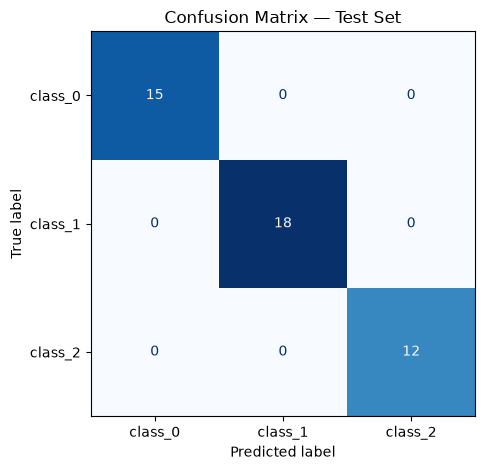

In [106]:
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

## 9. Inspect individual predictions
Look past the aggregate score — how confident is the model, and where (if anywhere) does it slip?

In [107]:
proba = best_model.predict_proba(X_test)

In [108]:
print("sample | true        | predicted   | confidence")
for i in range(8):
    print(f"{i:6d} | {target_names[y_test[i]]:11s} | {target_names[y_pred[i]]:11s} | {proba[i].max():.3f}")

sample | true        | predicted   | confidence
     0 | class_0     | class_0     | 0.950
     1 | class_1     | class_1     | 0.960
     2 | class_0     | class_0     | 0.930
     3 | class_0     | class_0     | 0.940
     4 | class_1     | class_1     | 1.000
     5 | class_0     | class_0     | 0.980
     6 | class_0     | class_0     | 0.990
     7 | class_1     | class_1     | 0.850


In [109]:
wrong = np.where(y_pred != y_test)[0]
print(f"Misclassified {len(wrong)} of {len(y_test)} test samples: {wrong}")
if len(wrong):
    i = wrong[0]
    print(f"\nSample {i}: true={target_names[y_test[i]]}, pred={target_names[y_pred[i]]}")
    print("class probabilities:", dict(zip(target_names, proba[i].round(3))))
else:
    print("No misclassifications on the test set.")

Misclassified 0 of 45 test samples: []
No misclassifications on the test set.


## 10. Feature importance

In [110]:
rf = best_model.named_steps["clf"]

In [111]:
importances = rf.feature_importances_

In [112]:
order = np.argsort(importances)[::-1]

In [113]:
print("Top 5 features:")
for i in order[:5]:
    print(f"  {feature_names[i]:25s}: {importances[i]:.4f}")

Top 5 features:
  color_intensity          : 0.1764
  flavanoids               : 0.1741
  alcohol                  : 0.1378
  proline                  : 0.1361
  hue                      : 0.1049


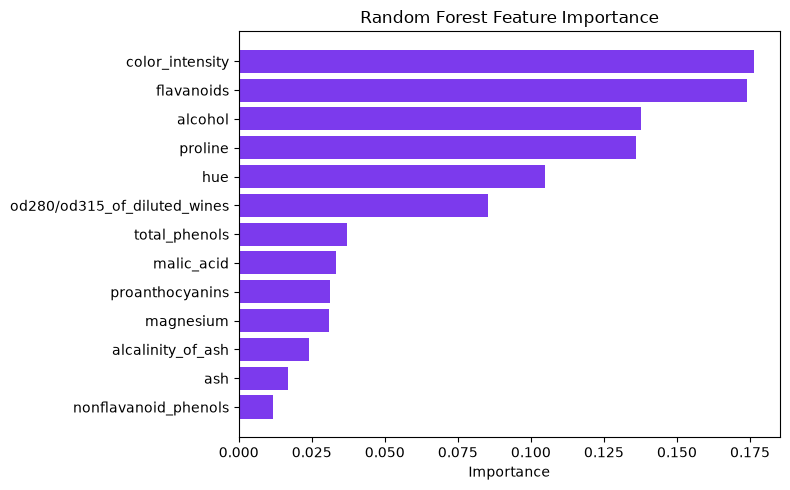

In [114]:
plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in order[::-1]], importances[order[::-1]], color="#7c3aed")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 11. Save, reload, and predict
Persist the trained model, load it back, and prove the reloaded copy behaves identically — this is what you'd ship.

In [115]:
joblib.dump(best_model, "wine_model.joblib")

['wine_model.joblib']

In [116]:
reloaded = joblib.load("wine_model.joblib")
print("Saved and reloaded: wine_model.joblib")

Saved and reloaded: wine_model.joblib


In [117]:
sample = X_test[[0]]   # one row, shape (1, 13)
pred = reloaded.predict(sample)[0]
print("Reloaded model prediction:", target_names[pred])
print("True label               :", target_names[y_test[0]])

Reloaded model prediction: class_0
True label               : class_0


In [118]:
assert (reloaded.predict(X_test) == best_model.predict(X_test)).all()
print("Reloaded model matches original on all test samples")
print("\nDone. Artifact: wine_model.joblib")

Reloaded model matches original on all test samples

Done. Artifact: wine_model.joblib
